In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import os

In [2]:
# import ctypes.util
# print(ctypes.util.find_library('libiomp5md'))

C:\Users\tanbi\anaconda3\Library\bin\libiomp5md.dll


In [4]:
df_anomalies = pd.read_csv(r"C:\Users\tanbi\door\hall_projects\cyfuture_pred_maintenance\Data\SAMP_MSL\labeled_anomalies.csv", encoding='utf-8')

In [5]:
# display unique telemetery channels
print(df_anomalies['chan_id'].unique())
print(len(df_anomalies['chan_id'].unique()))

['P-1' 'S-1' 'E-1' 'E-2' 'E-3' 'E-4' 'E-5' 'E-6' 'E-7' 'E-8' 'E-9' 'E-10'
 'E-11' 'E-12' 'E-13' 'A-1' 'D-1' 'P-2' 'P-3' 'D-2' 'D-3' 'D-4' 'A-2'
 'A-3' 'A-4' 'G-1' 'G-2' 'D-5' 'D-6' 'D-7' 'F-1' 'P-4' 'G-3' 'T-1' 'T-2'
 'D-8' 'D-9' 'F-2' 'G-4' 'T-3' 'D-11' 'D-12' 'B-1' 'G-6' 'G-7' 'P-7' 'R-1'
 'A-5' 'A-6' 'A-7' 'D-13' 'A-8' 'A-9' 'F-3' 'M-6' 'M-1' 'M-2' 'S-2' 'P-10'
 'T-4' 'T-5' 'F-7' 'M-3' 'M-4' 'M-5' 'P-15' 'C-1' 'C-2' 'T-12' 'T-13'
 'F-4' 'F-5' 'D-14' 'T-9' 'P-14' 'T-8' 'P-11' 'D-15' 'D-16' 'M-7' 'F-8']
81


In [6]:
df_anomalies[df_anomalies['chan_id'] == 'P-1']

,chan_id,spacecraft,anomaly_sequences,class,num_values
0,P-1,SMAP,"[[2149, 2349], [4536, 4844], [3539, 3779]]","[contextual, contextual, contextual]",8505


In [7]:
# sample data
sample_path = r"C:\Users\tanbi\door\hall_projects\cyfuture_pred_maintenance\Data\SAMP_MSL\data\train\P-1.npy"

data = np.load(sample_path)
print("data shape: ", data.shape)
print("Data: ", data[:5])

data shape:  (2872, 25)
Data:  [[-0.52315476  0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.        ]
 [-0.68885677  0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.        ]
 [-0.55499272  0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.        ]
 [-0.53111434  0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.


In [8]:
nonZero_cols = np.where(data.any(axis=0))[0]
print("number of non zero columns: ", len(nonZero_cols))
print(nonZero_cols)

number of non zero columns:  16
[ 0  1  2  3  5  6  7  9 11 13 14 17 18 19 21 22]


In [9]:
df = pd.DataFrame(data)
nonZero_df = df.iloc[:, nonZero_cols]

In [10]:
nonZero_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2872 entries, 0 to 2871
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       2872 non-null   float64
 1   1       2872 non-null   float64
 2   2       2872 non-null   float64
 3   3       2872 non-null   float64
 4   5       2872 non-null   float64
 5   6       2872 non-null   float64
 6   7       2872 non-null   float64
 7   9       2872 non-null   float64
 8   11      2872 non-null   float64
 9   13      2872 non-null   float64
 10  14      2872 non-null   float64
 11  17      2872 non-null   float64
 12  18      2872 non-null   float64
 13  19      2872 non-null   float64
 14  21      2872 non-null   float64
 15  22      2872 non-null   float64
dtypes: float64(16)
memory usage: 359.1 KB


In [11]:
nonZero_df.describe()

,0,1,2,3,5,6,7,9,11,13,14,17,18,19,21,22
count,2872.000000,2872.000000,2872.000000,2872.000000,2872.000000,2872.000000,2872.000000,2872.000000,2872.000000,2872.000000,2872.000000,2872.000000,2872.000000,2872.000000,2872.000000,2872.000000
mean,-0.427174,0.034123,0.005919,0.027855,0.157382,0.122911,0.001393,0.000696,0.001393,0.000696,0.000696,0.027855,0.027507,0.013928,0.038997,0.037256
std,0.402836,0.181576,0.076722,0.164586,0.364224,0.328392,0.037300,0.026384,0.037300,0.026384,0.026384,0.164586,0.163584,0.117211,0.193622,0.189422
min,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-0.737337,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,-0.574891,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,-0.189580,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [12]:
nonZero_df.head()

,0,1,2,3,5,6,7,9,11,13,14,17,18,19,21,22
0,-0.523155,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-0.688857,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-0.554993,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-0.531114,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-0.589001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


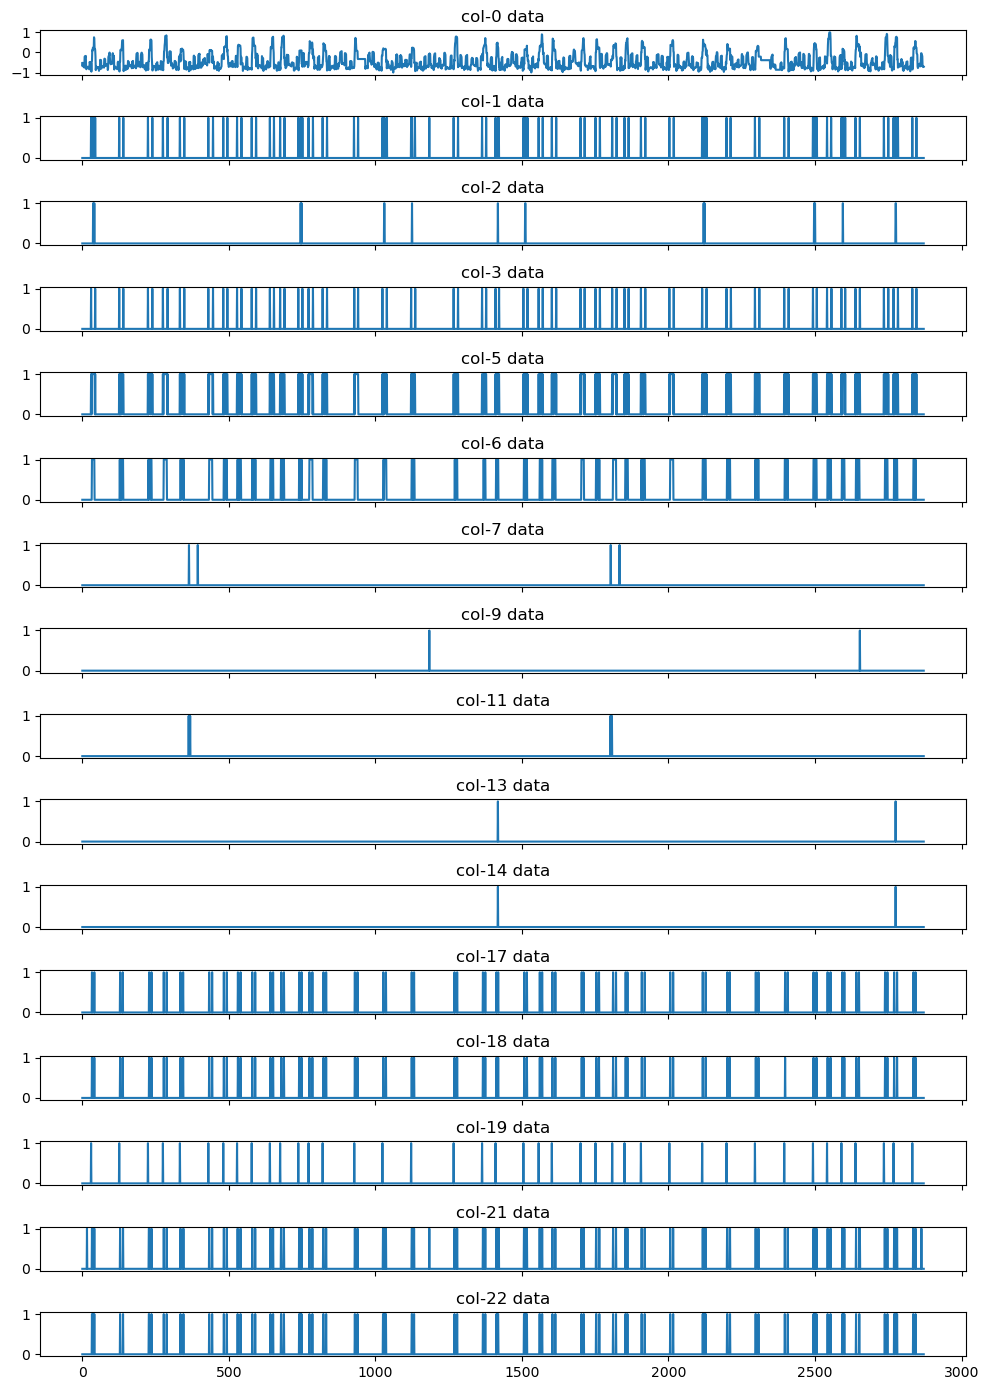

In [33]:
# visualization
fig, axes = plt.subplots(nrows=16, ncols=1, figsize=(10, 14), sharex=True)
for i, col in enumerate(nonZero_cols):
    axes[i].plot(data[:, col])
    axes[i].set_title(f"col-{col} data")
plt.tight_layout()
plt.show()

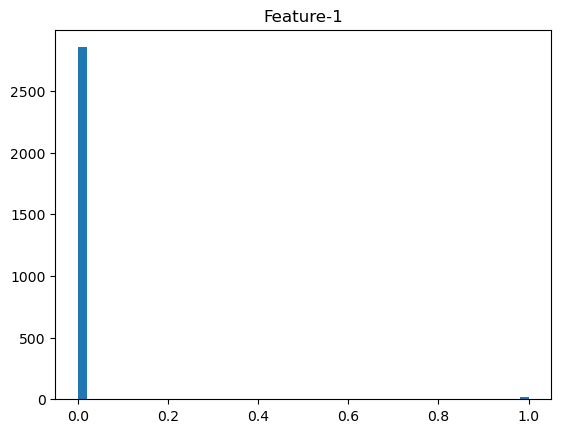

In [30]:
plt.hist(data[:, 2], bins=50)
plt.title("Feature-1")
plt.show()

In [ ]:
#  Feature 1 seems to be stationary